# Live LeRobot facade over a real dataset: ABC-130k

This notebook exercises the **live LeRobot facade** end to end against real
episodes from [ABC-130k](https://huggingface.co/datasets/XDOF/ABC-130k)
(XDOF, ~130k bimanual manipulation episodes, real MCAP/protobuf data) --
not a synthetic fixture.

Pipeline: **download -> ingest -> search (real fields) -> align -> live
facade -> real `torch.utils.data.DataLoader`.**

**Scope for this notebook:** state/action only (8 real joint/gripper topics
per episode, genuinely heterogeneous -- different vector widths per topic,
synchronized via `align.py`). Camera frames are explicitly **out of scope**
here: ABC-130k's cameras are real H.264/H.265 (inter-frame-dependent video),
different from the JPEG-per-message case the live facade's video path
(`schema_registry` + `video.py`) was built and proven against. See the
wrap-up cell at the end for details.

**Requirements:** a Hugging Face account with access granted to the gated
`XDOF/ABC-130k` dataset (request it on the dataset page), and `HF_TOKEN` set
or `huggingface-cli login`/`hf auth login` already run.


In [1]:
import json
import tempfile
from datetime import UTC, datetime
from pathlib import Path

import pyarrow as pa
import torch
from huggingface_hub import HfApi, hf_hub_download
from torch.utils.data import ConcatDataset, DataLoader

from lancedb_robotics.ingest import ingest_mcap
from lancedb_robotics.lake import Lake
from lancedb_robotics.lerobot_facade import CanonicalVectorMapping, LiveLeRobotFacade, to_torch_dataset
from lancedb_robotics.schemas import EPISODES_SCHEMA

REPO = "XDOF/ABC-130k"
TASKS = ["clip_the_socks_to_the_hanger", "fold_and_stack_the_towels", "erase_the_whiteboard"]
N_PER_TASK = 3

# The 8 real, heterogeneous state/action topics every ABC-130k episode carries.
STATE_TOPICS = ["/left-arm-state", "/right-arm-state", "/left-ee-state", "/right-ee-state"]
ACTION_TOPICS = ["/left-arm-action", "/right-arm-action", "/left-ee-action", "/right-ee-action"]
ALL_TOPICS = STATE_TOPICS + ACTION_TOPICS


/Users/sarwar/dev/lancedb-robotics-lakehouse/.venv-torch-0051/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download a real sample (gated dataset, cached locally)

Three distinct tasks, three episodes each -- real files from the actual
130k-episode corpus, not synthetic fixtures. `hf_hub_download` caches
locally, so re-running this cell is a no-op after the first download.


In [2]:
api = HfApi()
all_files = set(api.list_repo_files(REPO, repo_type="dataset"))

episodes_meta = []
for task in TASKS:
    ep_dirs = sorted({f.rsplit("/", 1)[0] for f in all_files if f.startswith(f"data/train/{task}/")})
    ep_dirs.sort(key=lambda d: f"{d}/annotation.mcap" not in all_files)  # annotated first
    for ep_dir in ep_dirs[:N_PER_TASK]:
        episode_uuid = ep_dir.rsplit("episode_", 1)[-1]
        episode_path = hf_hub_download(repo_id=REPO, repo_type="dataset", filename=f"{ep_dir}/episode.mcap")
        annotation_path = None
        if f"{ep_dir}/annotation.mcap" in all_files:
            annotation_path = hf_hub_download(
                repo_id=REPO, repo_type="dataset", filename=f"{ep_dir}/annotation.mcap"
            )
        episodes_meta.append(
            {
                "task": task,
                "episode_uuid": episode_uuid,
                "episode_path": episode_path,
                "annotation_path": annotation_path,
            }
        )

print(f"{len(episodes_meta)} episodes ready, {sum(1 for e in episodes_meta if e['annotation_path'])} annotated.")


9 episodes ready, 9 annotated.


## 2. Ingest into the lakehouse

One shared lake; each `episode.mcap`/`annotation.mcap` becomes its own
content-addressed `run_id`. This is where `schema_registry` persists every
message's real schema definition (so `payload_blob` stays re-decodable
without the source file), and where `extract.py`'s `RobotState`/
`GripperState` layouts (added this session) turn the raw protobuf into
typed `state_vector`/`action_vector` fields.


In [3]:
lake_dir = tempfile.mkdtemp()
lake = Lake.init(Path(lake_dir) / "abc130k.lance")

for meta in episodes_meta:
    report = ingest_mcap(lake, meta["episode_path"])
    assert not report.quarantined, meta
    meta["episode_run_id"] = report.run_id
    meta["message_count"] = report.message_count

    # One physical episode row spanning the whole run -- the facade's
    # episode/frame-index segmentation needs at least this to serve frames.
    bounds = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{report.run_id}'")
        .select(["timestamp_ns"])
        .to_arrow()
        .to_pylist()
    )
    ts = [row["timestamp_ns"] for row in bounds]
    instruction_row = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{report.run_id}' AND topic = '/instruction'")
        .select(["payload_json"])
        .limit(1)
        .to_arrow()
        .to_pylist()
    )
    task_text = json.loads(instruction_row[0]["payload_json"])["data"] if instruction_row else meta["task"]

    lake.table("episodes").add(
        pa.Table.from_pylist(
            [
                {
                    "episode_id": f"ep-{meta['episode_uuid']}",
                    "run_id": report.run_id,
                    "episode_index": 0,
                    "from_timestamp_ns": min(ts),
                    "to_timestamp_ns": max(ts),
                    "boundary_source": "abc130k-episode-mcap",
                    "outcome": "",
                    "frame_count": None,
                    "camera_blobs": [],
                    "task_id": task_text,
                    "embedding": None,
                    "provenance": "",
                    "transform_id": f"tfm-abc130k-{meta['episode_uuid']}",
                    "created_at": datetime.now(UTC),
                }
            ],
            schema=EPISODES_SCHEMA,
        )
    )

    if meta["annotation_path"]:
        ann_report = ingest_mcap(lake, meta["annotation_path"])
        meta["annotation_run_id"] = ann_report.run_id
    else:
        meta["annotation_run_id"] = None

    print(f"{meta['task']:32s} {meta['episode_uuid'][:8]}  {report.message_count:5d} msgs  task='{task_text}'")


clip_the_socks_to_the_hanger     01689f63  18671 msgs  task='clip the socks to the hanger'


clip_the_socks_to_the_hanger     01b65296  32729 msgs  task='clip the socks to the hanger'


clip_the_socks_to_the_hanger     03e7f873  25524 msgs  task='clip the socks to the hanger'


fold_and_stack_the_towels        0104361e  54608 msgs  task='fold and stack the towels'


fold_and_stack_the_towels        0120c17c  66598 msgs  task='fold and stack the towels'


fold_and_stack_the_towels        02e198aa  34412 msgs  task='fold and stack the towels'


erase_the_whiteboard             0061f465  47425 msgs  task='erase the whiteboard'


erase_the_whiteboard             0161e19f  44785 msgs  task='erase the whiteboard'


erase_the_whiteboard             0250ec75  49559 msgs  task='erase the whiteboard'


### Confirm the real fix: typed state/action vectors, not NULL

Before this session, `RobotState`/`GripperState` weren't in `extract.py`'s
layout table -- every ABC-130k observation decoded fine but
`state_vector`/`action_vector`/`modality` came back NULL/"unknown". Real
proof that's fixed:


In [4]:
sample_run_id = episodes_meta[0]["episode_run_id"]
for topic in ["/left-arm-state", "/left-ee-action"]:
    row = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{sample_run_id}' AND topic = '{topic}'")
        .select(["topic", "modality", "state_vector", "action_vector"])
        .limit(1)
        .to_arrow()
        .to_pylist()[0]
    )
    print(row)


{'topic': '/left-arm-state', 'modality': 'joint_state', 'state_vector': [-0.5758373141288757, 0.8463035225868225, 0.6845578551292419, -0.1203555315732956, 0.2798123061656952, -0.8199816942214966], 'action_vector': None}
{'topic': '/left-ee-action', 'modality': 'gripper', 'state_vector': [0.9474506378173828], 'action_vector': None}


## 3. See the corpus before you query it

Before any search, alignment, or quality machinery runs: a direct look at
what these 9 real ABC-130k episodes actually contain -- real robot
workspaces, real joint motion, real variation in episode length. Nothing
below is synthetic or cherry-picked; it is exactly what falls out of the
lakehouse for these episodes.


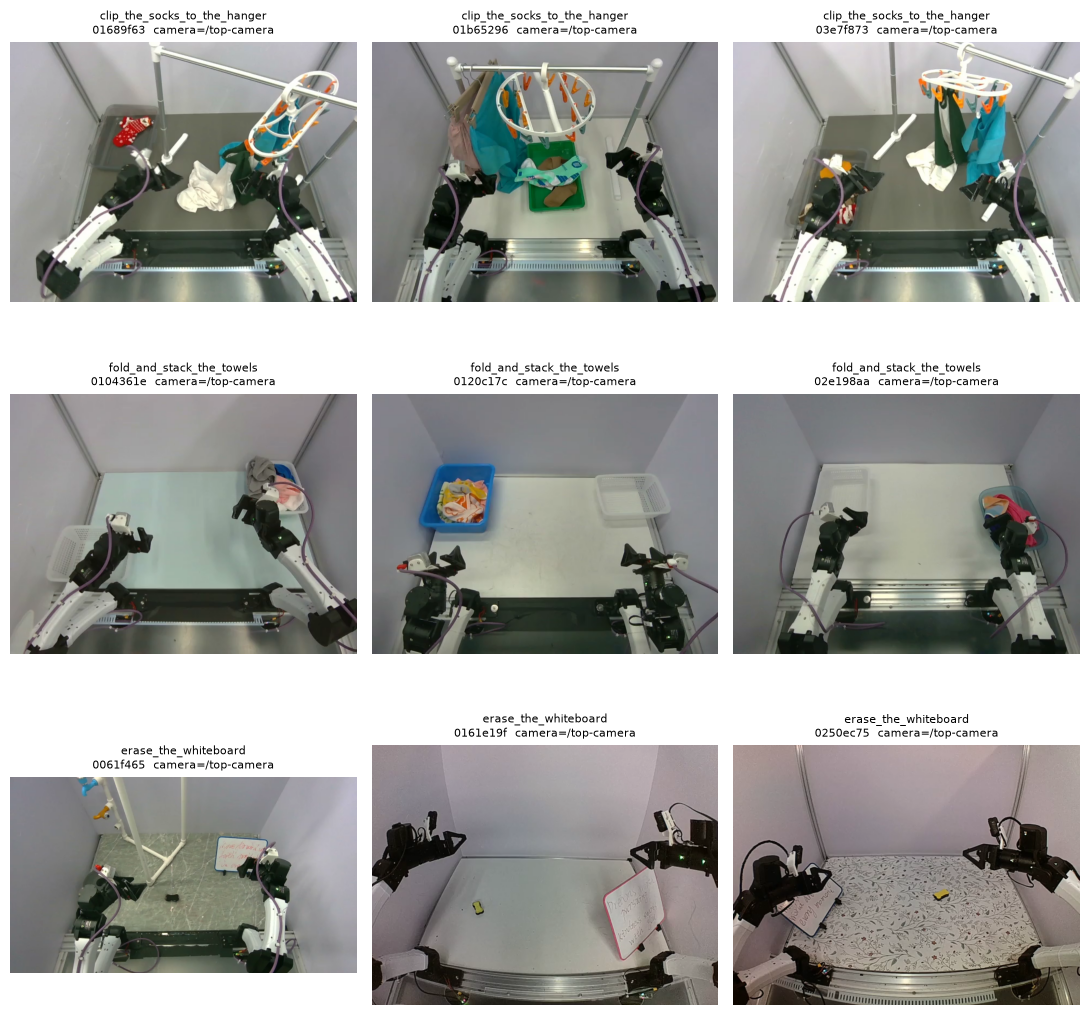

In [5]:
import av
import matplotlib.pyplot as plt

from lancedb_robotics.blob import fetch_blob
from lancedb_robotics.schema_registry import redecode_payload_blob

TOP_CAMERA_CANDIDATES = ["/top-camera", "/top-left-camera"]


def pick_top_camera_topic(run_id):
    for topic in TOP_CAMERA_CANDIDATES:
        n = (
            lake.table("observations")
            .search()
            .where(f"run_id = '{run_id}' AND topic = '{topic}'")
            .select(["timestamp_ns"])
            .limit(1)
            .to_arrow()
            .num_rows
        )
        if n:
            return topic
    return None


def decode_first_camera_frame_rgb(run_id, topic):
    """Decode only the first (guaranteed-keyframe) message on `topic`."""
    ts_rows = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{run_id}' AND topic = '{topic}'")
        .select(["timestamp_ns"])
        .to_arrow()
        .to_pylist()
    )
    if not ts_rows:
        return None
    first_ts = min(row["timestamp_ns"] for row in ts_rows)
    meta_rows = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{run_id}' AND topic = '{topic}' AND timestamp_ns = {first_ts}")
        .select(["observation_id", "schema_digest", "message_encoding"])
        .limit(1)
        .to_arrow()
        .to_pylist()
    )
    if not meta_rows:
        return None
    row = meta_rows[0]
    row["payload_blob"] = fetch_blob(
        lake.table("observations"), "payload_blob", row["observation_id"], id_column="observation_id"
    )
    result = redecode_payload_blob(lake, row)
    if result.status != "decoded" or not result.blobs:
        return None

    codec_format = json.loads(result.payload_json)["format"]
    codec_name = "hevc" if codec_format == "h265" else "h264"
    ctx = av.CodecContext.create(codec_name, "r")
    # This one message *is* one complete access unit (parameter sets + IDR
    # slice, per YAM_DATA_FORMAT.md) -- wrap it directly as a single Packet
    # rather than feeding it through `ctx.parse()`, which is a *streaming*
    # Annex-B parser: it buffers until it sees the *next* access unit's start
    # code before it will emit anything, which never arrives for a lone frame.
    decoded = ctx.decode(av.Packet(result.blobs[0]))
    return decoded[0].to_ndarray(format="rgb24") if decoded else None


fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, meta in zip(axes.flat, episodes_meta):
    topic = pick_top_camera_topic(meta["episode_run_id"])
    frame = decode_first_camera_frame_rgb(meta["episode_run_id"], topic) if topic else None
    if frame is not None:
        ax.imshow(frame)
    else:
        ax.text(0.5, 0.5, "no frame", ha="center", va="center")
    ax.set_title(f"{meta['task']}\n{meta['episode_uuid'][:8]}  camera={topic}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


**Real joint/gripper motion** for one episode -- `state_vector`s already
typed by this session's `extract.py` extension, read straight from
`observations`; no alignment or facade needed for this view.


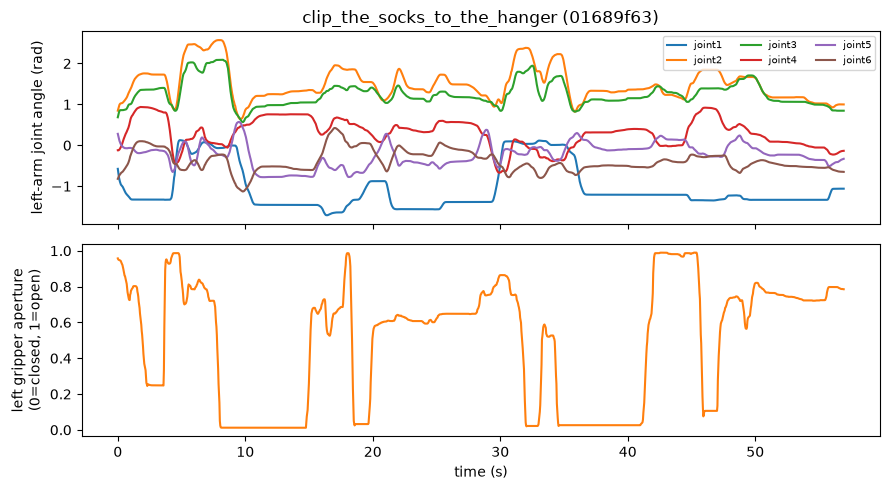

In [6]:
sample_meta = episodes_meta[0]


def load_state_trajectory(run_id, topic):
    rows = (
        lake.table("observations")
        .search()
        .where(f"run_id = '{run_id}' AND topic = '{topic}'")
        .select(["timestamp_ns", "state_vector"])
        .to_arrow()
        .to_pylist()
    )
    rows.sort(key=lambda r: r["timestamp_ns"])
    t0 = rows[0]["timestamp_ns"]
    times = [(r["timestamp_ns"] - t0) / 1e9 for r in rows]
    return times, [r["state_vector"] for r in rows]


arm_times, arm_values = load_state_trajectory(sample_meta["episode_run_id"], "/left-arm-state")
gripper_times, gripper_values = load_state_trajectory(sample_meta["episode_run_id"], "/left-ee-state")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for j in range(6):
    ax1.plot(arm_times, [v[j] for v in arm_values], label=f"joint{j + 1}")
ax1.set_ylabel("left-arm joint angle (rad)")
ax1.set_title(f"{sample_meta['task']} ({sample_meta['episode_uuid'][:8]})")
ax1.legend(loc="upper right", fontsize=7, ncol=3)

ax2.plot(gripper_times, [v[0] for v in gripper_values], color="tab:orange")
ax2.set_ylabel("left gripper aperture\n(0=closed, 1=open)")
ax2.set_xlabel("time (s)")
plt.tight_layout()
plt.show()


**Real variation in episode length** across the corpus -- not synthetic,
not uniform. This is exactly why "genuinely shorter than its peers" is a
checkable signal later on (the quality-gate section), not a fabricated
label.


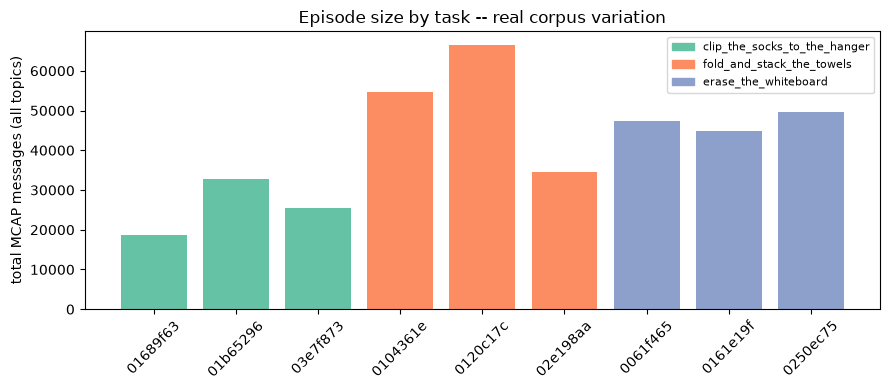

In [7]:
tasks_unique = list(dict.fromkeys(meta["task"] for meta in episodes_meta))
palette = dict(zip(tasks_unique, plt.cm.Set2.colors))

fig, ax = plt.subplots(figsize=(9, 4))
labels = [meta["episode_uuid"][:8] for meta in episodes_meta]
values = [meta["message_count"] for meta in episodes_meta]
bar_colors = [palette[meta["task"]] for meta in episodes_meta]
ax.bar(labels, values, color=bar_colors)
ax.set_ylabel("total MCAP messages (all topics)")
ax.set_title("Episode size by task -- real corpus variation")
ax.tick_params(axis="x", rotation=45)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=palette[t]) for t in tasks_unique],
    labels=tasks_unique,
    fontsize=8,
)
plt.tight_layout()
plt.show()


## 4. Search episodes -- real fields, no fabricated labels

ABC-130k has no success/failure label anywhere (confirmed from
`docs/YAM_DATA_FORMAT.md`) -- only the task instruction and, for ~1/3 of
episodes, subtask segment labels. Both are genuine MCAP channels
(`/instruction`, `/subtask-annotation`), decoded like any other observation
-- "search" here is a real query over `observations`, not a special
feature.

**By task instruction:**


In [8]:
by_task = {}
for meta in episodes_meta:
    by_task.setdefault(meta["task"], []).append(meta["episode_uuid"][:8])
for task, eps in by_task.items():
    print(f"{task:32s} {len(eps)} episode(s): {eps}")


clip_the_socks_to_the_hanger     3 episode(s): ['01689f63', '01b65296', '03e7f873']
fold_and_stack_the_towels        3 episode(s): ['0104361e', '0120c17c', '02e198aa']
erase_the_whiteboard             3 episode(s): ['0061f465', '0161e19f', '0250ec75']


**By subtask label** (temporal: which episodes contain a subtask mentioning
a given word, and *when* in the episode it happens):


In [9]:
def search_subtask(keyword: str):
    hits = []
    for meta in episodes_meta:
        if not meta["annotation_run_id"]:
            continue
        rows = (
            lake.table("observations")
            .search()
            .where(f"run_id = '{meta['annotation_run_id']}'")
            .select(["timestamp_ns", "payload_json"])
            .to_arrow()
            .to_pylist()
        )
        for row in sorted(rows, key=lambda r: r["timestamp_ns"]):
            label = json.loads(row["payload_json"])["data"]
            if keyword.lower() in label.lower():
                hits.append((meta["task"], meta["episode_uuid"][:8], label))
    return hits


for task, ep, label in search_subtask("fold"):
    print(f"{task:32s} {ep}  \"{label}\"")


fold_and_stack_the_towels        0104361e  "fold the towel"
fold_and_stack_the_towels        0104361e  "Neatly place the folded towel into the bin"
fold_and_stack_the_towels        0104361e  "fold the towel"
fold_and_stack_the_towels        0104361e  "Neatly place the folded towel into the bin"
fold_and_stack_the_towels        0104361e  "fold the towel"
fold_and_stack_the_towels        0104361e  "Neatly place the folded towel into the bin"
fold_and_stack_the_towels        0120c17c  "fold the towel"
fold_and_stack_the_towels        0120c17c  "Neatly place the folded towel into the bin"
fold_and_stack_the_towels        0120c17c  "fold the towel"
fold_and_stack_the_towels        0120c17c  "Neatly place the folded towel into the bin"
fold_and_stack_the_towels        0120c17c  "fold the towel"
fold_and_stack_the_towels        0120c17c  "Neatly place the folded towel into the bin"
fold_and_stack_the_towels        0120c17c  "fold the towel"
fold_and_stack_the_towels        0120c17c  "Neatly p

## 5. Align each episode

Every episode's 8 state/action topics run on the *same* ~30 Hz control
loop (confirmed on real data), so a tight-tolerance nearest-neighbor
alignment is enough. This is `align.py`'s existing multi-rate
reconciliation -- not new this session -- doing exactly what it's for:
turning "8 independently-timestamped topics" into "one synchronized tick
per instant."


In [10]:
for meta in episodes_meta:
    view_name = f"abc_{meta['episode_uuid'][:8]}"
    lake.align.create_view(
        view_name,
        run_id=meta["episode_run_id"],
        rate_hz=30.0,
        streams=ALL_TOPICS,
        tolerance_ms=20.0,
        interpolation={topic: "nearest" for topic in ALL_TOPICS},
    )
    meta["alignment_name"] = view_name

print(f"{len(episodes_meta)} alignments created.")


9 alignments created.


## 6. The live LeRobot facade

One `LiveLeRobotFacade` per episode: `observation.state` is the 4
observation topics concatenated (arm+arm+gripper+gripper = 6+6+1+1 = 14
floats), `action` is the 4 commanded topics the same way. No export step --
this reads `aligned_ticks` directly.


In [11]:
mapping = CanonicalVectorMapping(
    state_streams=tuple(STATE_TOPICS),
    action_streams=tuple(ACTION_TOPICS),
)

facades = []
for meta in episodes_meta:
    facade = LiveLeRobotFacade(lake, name=meta["alignment_name"], mapping=mapping)
    facades.append(facade)
    meta["frames"] = len(facade)

for meta in episodes_meta:
    print(f"{meta['task']:32s} {meta['episode_uuid'][:8]}  {meta['frames']:4d} frames")

item0 = facades[0][0]
print()
print("one item:", {k: (v if not isinstance(v, list) else f"list[{len(v)}]") for k, v in item0.items()})


clip_the_socks_to_the_hanger     01689f63  1707 frames
clip_the_socks_to_the_hanger     01b65296  3003 frames
clip_the_socks_to_the_hanger     03e7f873  2336 frames
fold_and_stack_the_towels        0104361e  4996 frames
fold_and_stack_the_towels        0120c17c  6090 frames
fold_and_stack_the_towels        02e198aa  3126 frames
erase_the_whiteboard             0061f465  4351 frames
erase_the_whiteboard             0161e19f  4101 frames
erase_the_whiteboard             0250ec75  4534 frames

one item: {'episode_index': 0, 'frame_index': 0, 'index': 0, 'timestamp': 1751060476.0987456, 'task': 'clip the socks to the hanger', 'observation.state': 'list[14]', 'action': 'list[14]'}


## 7. Combine episodes + a real `torch.utils.data.DataLoader`

`to_torch_dataset` wraps each episode's facade as a real
`torch.utils.data.Dataset`; `ConcatDataset` (standard PyTorch, not
something this repo adds) combines all 9 episodes into one dataset a
training loop would actually iterate.


In [12]:
torch_datasets = [to_torch_dataset(facade) for facade in facades]
combined = ConcatDataset(torch_datasets)
print(f"combined dataset: {len(combined)} frames across {len(torch_datasets)} episodes")

# Direct proof ConcatDataset really spans independent per-episode facades:
# check right at the episode-0/episode-1 boundary (batches alone won't show
# this -- episode 0 alone has 1707 frames, far more than one batch).
#
# Note: `episode_index` is *local* to each underlying facade -- every
# episode.mcap here is its own physical episode, so each per-file facade
# only ever has one episode (index 0). It does NOT become a global index
# just because ConcatDataset stitches several facades together. frame_index
# resetting to 0 is still real proof of a genuine episode transition; we
# additionally print each side's own episode UUID (which *is* globally
# unique) to make the transition unambiguous.
boundary = len(facades[0])
last_of_ep0 = combined[boundary - 1]
first_of_ep1 = combined[boundary]
print(
    f"frame {boundary - 1}: episode uuid={episodes_meta[0]['episode_uuid'][:8]} "
    f"frame_index={last_of_ep0['frame_index']} task='{last_of_ep0['task']}'"
)
print(
    f"frame {boundary}:  episode uuid={episodes_meta[1]['episode_uuid'][:8]} "
    f"frame_index={first_of_ep1['frame_index']} task='{first_of_ep1['task']}'"
)

loader = DataLoader(combined, batch_size=8, shuffle=False)
for i, batch in enumerate(loader):
    print(
        f"batch {i}: observation.state {tuple(batch['observation.state'].shape)}"
        f" ({batch['observation.state'].dtype}),"
        f" action {tuple(batch['action'].shape)}"
    )
    if i >= 2:
        break


combined dataset: 34244 frames across 9 episodes
frame 1706: episode uuid=01689f63 frame_index=1706 task='clip the socks to the hanger'
frame 1707:  episode uuid=01b65296 frame_index=0 task='clip the socks to the hanger'
batch 0: observation.state (8, 14) (torch.float32), action (8, 14)
batch 1: observation.state (8, 14) (torch.float32), action (8, 14)
batch 2: observation.state (8, 14) (torch.float32), action (8, 14)


## 8. A real "failure" signal: the data-quality gate

ABC-130k has no success/failure label (confirmed above). But a fleet of
episodes still has a genuine, checkable notion of "not usable for
training" -- `quality.py`'s pre-existing validation gate (required-topic
coverage, monotonic timestamps, cross-stream overlap, run integrity). We
set the bar here from the corpus itself, not a hardcoded guess: each
topic's threshold is the *median* real message count for that topic across
these 9 episodes, so any episode that's meaningfully shorter than its
peers on any of the 8 state/action topics genuinely fails -- a real signal
from real timing data, not a fabricated label.


In [13]:
import statistics

from lancedb_robotics import quality

QUALITY_PROFILE_NAME = "abc130k-state-action-coverage"

topic_counts = {topic: [] for topic in ALL_TOPICS}
for meta in episodes_meta:
    for topic in ALL_TOPICS:
        n = (
            lake.table("observations")
            .search()
            .where(f"run_id = '{meta['episode_run_id']}' AND topic = '{topic}'")
            .select(["timestamp_ns"])
            .to_arrow()
            .num_rows
        )
        topic_counts[topic].append(n)

profile = quality.ValidationProfile(
    name=QUALITY_PROFILE_NAME,
    required_topics=tuple(
        quality.RequiredTopic(topic=topic, min_count=int(statistics.median(counts)))
        for topic, counts in topic_counts.items()
    ),
    require_monotonic=True,
    require_overlap=True,
)

reports = [quality.validate_run(lake, meta["episode_run_id"], profile) for meta in episodes_meta]
# Write verdicts back to the lake -- runs.quality_flags, observations.quality_flags,
# and the full per-rule report as durable transform_runs lineage. Every later cell
# reads this back fresh from the lake instead of keeping a Python-side copy.
quality.apply_quality_results(lake, reports, profile)

n_passed = sum(1 for report in reports if report.passed)
print(f"{n_passed}/{len(episodes_meta)} episodes pass the quality gate (written to `runs.quality_flags`)\n")
for meta, report in zip(episodes_meta, reports):
    verdict = "PASS" if report.passed else "FAIL"
    print(f"{verdict:4s} {meta['task']:32s} {meta['episode_uuid'][:8]}  {meta['frames']:4d} frames")
    for rule in report.failed_rules:
        print(f"       failed: {rule.rule} -- {'; '.join(rule.details)}")


5/9 episodes pass the quality gate (written to `runs.quality_flags`)

FAIL clip_the_socks_to_the_hanger     01689f63  1707 frames
       failed: required-topics -- /left-arm-state: 1697 messages < required 4071; /right-arm-state: 1697 messages < required 4071; /left-ee-state: 1697 messages < required 4071; /right-ee-state: 1697 messages < required 4071; /left-arm-action: 1697 messages < required 4071; /right-arm-action: 1697 messages < required 4071; /left-ee-action: 1697 messages < required 4071; /right-ee-action: 1697 messages < required 4071
FAIL clip_the_socks_to_the_hanger     01b65296  3003 frames
       failed: required-topics -- /left-arm-state: 2975 messages < required 4071; /right-arm-state: 2975 messages < required 4071; /left-ee-state: 2975 messages < required 4071; /right-ee-state: 2975 messages < required 4071; /left-arm-action: 2975 messages < required 4071; /right-arm-action: 2975 messages < required 4071; /left-ee-action: 2975 messages < required 4071; /right-ee-action

## 9. Search results a researcher can actually validate: thumbnails + structured cards

Real fields (task, quality verdict, subtask hits) plus a **real decoded
video frame**, not raw compressed bytes. Every camera topic here is genuine
H.264/H.265 (Annex B, inter-frame dependent) -- explicitly out of scope for
full playback in this notebook (see the wrap-up). But the *first* message
on any ABC-130k camera stream is documented (`YAM_DATA_FORMAT.md`) to always
be a keyframe with parameter sets prepended, so it alone is independently
decodable. We decode exactly that one frame per episode with `pyav`, via
the same real, schema-registry-backed re-decode path (`redecode_payload_blob`)
the live facade's video support already proved -- no raw_uri access, no
full-stream decode.


In [14]:
import matplotlib.pyplot as plt


def lake_quality_failure_reasons(run_id):
    """Real per-rule failure details for one run, read fresh from `transform_runs` --
    the full report `apply_quality_results` wrote there, not a Python-side copy."""
    transform_id = f"tfm-quality-{QUALITY_PROFILE_NAME}-{run_id.removeprefix('run-')}"
    rows = (
        lake.table("transform_runs")
        .search()
        .where(f"transform_id = '{transform_id}'")
        .select(["params"])
        .limit(1)
        .to_arrow()
        .to_pylist()
    )
    if not rows:
        return []
    report = json.loads(rows[0]["params"])["report"]
    return [rule for rule in report["rules"] if rule["status"] == "failed"]


def show_result_cards(matches):
    if not matches:
        print("no matches")
        return
    quarantined = set(quality.quarantined_run_ids(lake))  # real lake read, not cached in Python
    fig, axes = plt.subplots(1, len(matches), figsize=(4 * len(matches), 4))
    axes = [axes] if len(matches) == 1 else list(axes)
    for ax, meta in zip(axes, matches):
        topic = pick_top_camera_topic(meta["episode_run_id"])
        frame = decode_first_camera_frame_rgb(meta["episode_run_id"], topic) if topic else None
        if frame is not None:
            ax.imshow(frame)
        else:
            ax.text(0.5, 0.5, "no frame", ha="center", va="center")
        verdict = "FAIL" if meta["episode_run_id"] in quarantined else "PASS"
        ax.set_title(
            f"{meta['task']}\n{meta['episode_uuid'][:8]}  quality={verdict}\n{meta['frames']} frames"
            + (f"\ncamera={topic}" if topic else ""),
            fontsize=8,
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()


3 match(es) for task='towel' subtask=None quality_passed=None:

- fold_and_stack_the_towels        0104361e  quality=PASS  frames=4996
- fold_and_stack_the_towels        0120c17c  quality=PASS  frames=6090
- fold_and_stack_the_towels        02e198aa  quality=FAIL  frames=3126
    failed: required-topics -- /left-arm-state: 3128 messages < required 4071; /right-arm-state: 3128 messages < required 4071; /left-ee-state: 3128 messages < required 4071; /right-ee-state: 3128 messages < required 4071; /left-arm-action: 3128 messages < required 4071; /right-arm-action: 3128 messages < required 4071; /left-ee-action: 3128 messages < required 4071; /right-ee-action: 3128 messages < required 4071


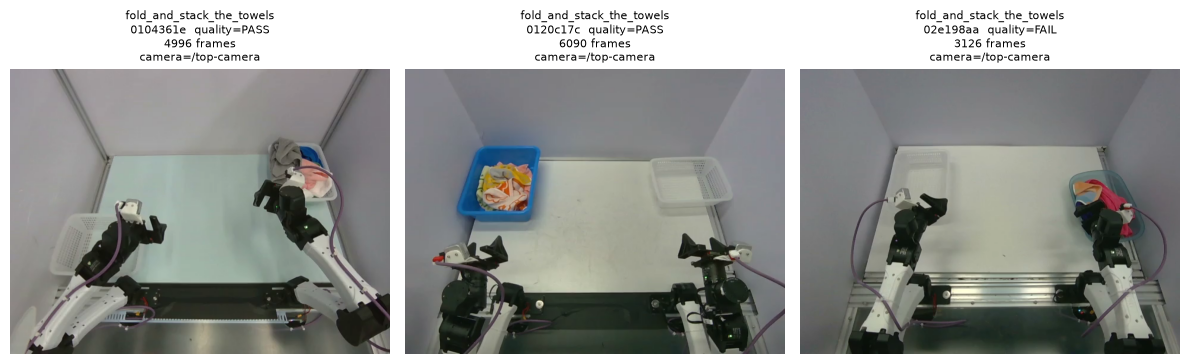

4 match(es) for task=None subtask=None quality_passed=False:

- clip_the_socks_to_the_hanger     01689f63  quality=FAIL  frames=1707
    failed: required-topics -- /left-arm-state: 1697 messages < required 4071; /right-arm-state: 1697 messages < required 4071; /left-ee-state: 1697 messages < required 4071; /right-ee-state: 1697 messages < required 4071; /left-arm-action: 1697 messages < required 4071; /right-arm-action: 1697 messages < required 4071; /left-ee-action: 1697 messages < required 4071; /right-ee-action: 1697 messages < required 4071
- clip_the_socks_to_the_hanger     01b65296  quality=FAIL  frames=3003
    failed: required-topics -- /left-arm-state: 2975 messages < required 4071; /right-arm-state: 2975 messages < required 4071; /left-ee-state: 2975 messages < required 4071; /right-ee-state: 2975 messages < required 4071; /left-arm-action: 2975 messages < required 4071; /right-arm-action: 2975 messages < required 4071; /left-ee-action: 2975 messages < required 4071; /right-e

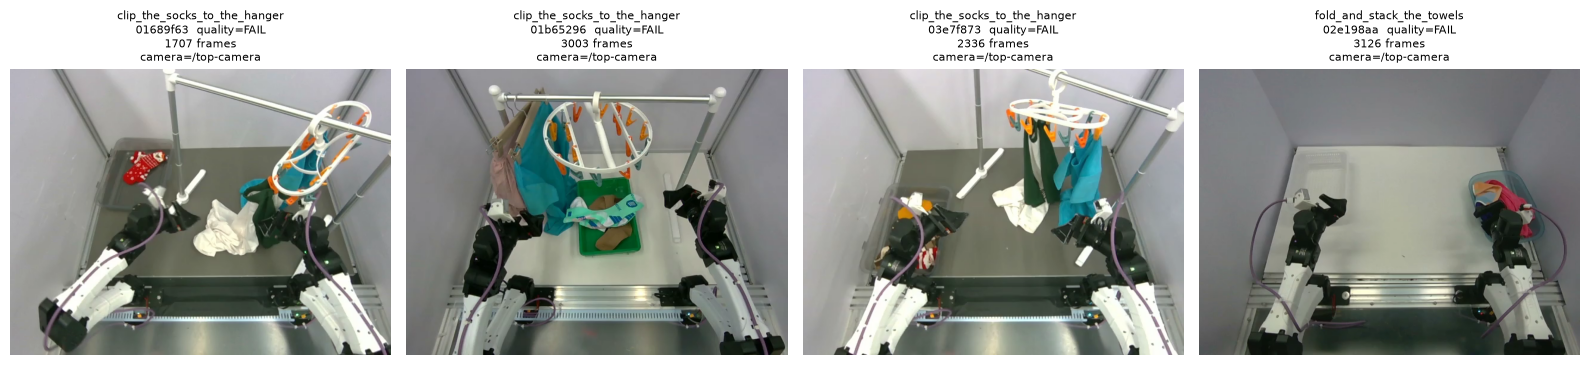

In [15]:
def search_and_show(task_keyword=None, subtask_keyword=None, quality_passed=None):
    quarantined = set(quality.quarantined_run_ids(lake))  # real lake read, not cached in Python
    matches = []
    for meta in episodes_meta:
        task_hit = task_keyword is None or task_keyword.lower() in meta["task"].lower()
        subtask_hits = []
        if meta["annotation_run_id"] and subtask_keyword:
            rows = (
                lake.table("observations")
                .search()
                .where(f"run_id = '{meta['annotation_run_id']}'")
                .select(["timestamp_ns", "payload_json"])
                .to_arrow()
                .to_pylist()
            )
            for row in sorted(rows, key=lambda r: r["timestamp_ns"]):
                label = json.loads(row["payload_json"])["data"]
                if subtask_keyword.lower() in label.lower():
                    subtask_hits.append(label)
        subtask_hit = subtask_keyword is None or bool(subtask_hits)
        passed = meta["episode_run_id"] not in quarantined
        quality_hit = quality_passed is None or passed == quality_passed
        if task_hit and subtask_hit and quality_hit:
            meta["_subtask_hits"] = subtask_hits
            matches.append(meta)

    print(
        f"{len(matches)} match(es) for task={task_keyword!r} subtask={subtask_keyword!r} "
        f"quality_passed={quality_passed!r}:\n"
    )
    for meta in matches:
        passed = meta["episode_run_id"] not in quarantined
        verdict = "PASS" if passed else "FAIL"
        print(f"- {meta['task']:32s} {meta['episode_uuid'][:8]}  quality={verdict}  frames={meta['frames']}")
        if meta.get("_subtask_hits"):
            for label in meta["_subtask_hits"]:
                print(f"    subtask match: \"{label}\"")
        if not passed:
            for rule in lake_quality_failure_reasons(meta["episode_run_id"]):
                print(f"    failed: {rule['rule']} -- {'; '.join(rule['details'])}")
    show_result_cards(matches)
    return matches


_ = search_and_show(task_keyword="towel")
_ = search_and_show(quality_passed=False)


## 10. Curate a named, durable view over the quality-passing episodes

`curate.py`'s real workbench operates at **scenario** grain (joined to
`runs`), not episode/run directly -- so each physical episode first gets
exactly one whole-episode `scenarios` row via
`scenarios.create_scenario_windows` (window wider than any episode's real
duration, so windowing never splits an episode). The quality verdict from
section 7 is a precomputed, per-episode criterion -- not the kind of thing
`curate.py`'s equality/membership predicates express directly -- so we pass
the matching scenario ids straight into a `CurationScope`, then persist the
selection as a named `CurationView` any later reader (this notebook, a
training job, another researcher) can reopen by name.


In [16]:
from lancedb_robotics.curate import CurationScope
from lancedb_robotics.scenarios import create_scenario_windows, parse_duration_ns

scenario_report = create_scenario_windows(lake, window_ns=parse_duration_ns("30m"), include_partial=True)
print(scenario_report)

run_to_scenario = {}
for row in lake.table("scenarios").to_arrow().to_pylist():
    run_to_scenario.setdefault(row["run_id"], row["scenario_id"])

quarantined = set(quality.quarantined_run_ids(lake))  # real lake read
passing_scenario_ids = tuple(
    run_to_scenario[meta["episode_run_id"]]
    for meta in episodes_meta
    if meta["episode_run_id"] not in quarantined
)
scope = CurationScope(scenario_ids=passing_scenario_ids)
selection = lake.curate.workbench(scope=scope)
view = selection.save_view(
    "abc130k_training_ready",
    description="ABC-130k episodes passing the state/action coverage quality gate",
    tags=("demo", "abc130k"),
)
print(f"saved view {view.name!r}: {view.membership_count} scenario(s), status={view.status!r}")

# Reopen it fresh -- proves the view is durable in the lake, not a Python object.
reopened = lake.curate.view("abc130k_training_ready")
assert set(reopened.scenario_ids) == set(passing_scenario_ids)
print("reopened membership:", reopened.scenario_ids)


ScenarioWindowReport(lake_uri='/var/folders/n8/6q91s9mj5r557f40145k5g240000gn/T/tmpgczpt7ln/abc130k.lance', transform_id='tfm-scenarios-54b43eeed8b653ca', window_ns=1800000000000, topics=(), include_partial=True, runs_considered=18, rows_added=18, rows_replaced=0, windows_by_run={'run-03d3fa05755e3116': 1, 'run-2636b706bd69fdea': 1, 'run-5cbae4868bccf49a': 1, 'run-6e2b0708a57e1f78': 1, 'run-7fb638d2483da245': 1, 'run-8082fce3d628f4be': 1, 'run-8cdc1a3dcd37503b': 1, 'run-b2d24573b966538a': 1, 'run-c3df267f8bca55a8': 1, 'run-c4e47daedd9de0b0': 1, 'run-d64bd93f703722f4': 1, 'run-dba28b023e27d712': 1, 'run-e01034e8e3e7a3d1': 1, 'run-e18b1fd1809a54fd': 1, 'run-e3830fd28595792c': 1, 'run-e9870d2f7e6deaf1': 1, 'run-eccf4fa915a63c72': 1, 'run-f346d5c9f0dc79ad': 1})


saved view 'abc130k_training_ready': 5 scenario(s), status='active'
reopened membership: ('scn-e0cbe52195671597', 'scn-434d1cb36a7e3b07', 'scn-a912f2f1763d2955', 'scn-4b09d113043d14e7', 'scn-f0e7e2cfdff15abd')


## 11. A filtered `DataLoader` from the curated view -- zero copies, zero shards

The curated view names a *subset* of episodes. Serving it is nothing more
than choosing which of the per-episode facades already open in memory (from
section 5) to hand to `ConcatDataset` -- no new files, no export step, no
shard directory. The `CurationView` is the reusable, durable filter; the
live facades underneath are unchanged.


In [17]:
scenario_to_run = {scenario_id: run_id for run_id, scenario_id in run_to_scenario.items()}
curated_run_ids = {scenario_to_run[sid] for sid in reopened.scenario_ids}

curated_datasets = [
    to_torch_dataset(facade)
    for facade, meta in zip(facades, episodes_meta)
    if meta["episode_run_id"] in curated_run_ids
]
curated_combined = ConcatDataset(curated_datasets)
print(
    f"curated dataset: {len(curated_combined)} frames across "
    f"{len(curated_datasets)}/{len(facades)} episodes -- selected via the saved "
    "CurationView, reusing the same live facades from section 5 (no copies, no shards, no export)."
)

curated_loader = DataLoader(curated_combined, batch_size=8, shuffle=False)
for i, batch in enumerate(curated_loader):
    print(
        f"batch {i}: observation.state {tuple(batch['observation.state'].shape)}"
        f" ({batch['observation.state'].dtype}), action {tuple(batch['action'].shape)}"
    )
    if i >= 1:
        break


curated dataset: 24072 frames across 5/9 episodes -- selected via the saved CurationView, reusing the same live facades from section 5 (no copies, no shards, no export).
batch 0: observation.state (8, 14) (torch.float32), action (8, 14)
batch 1: observation.state (8, 14) (torch.float32), action (8, 14)


## Wrap-up

What this notebook proved, on a real, gated, external dataset it had never
seen before this session:

- **Ingest**: real protobuf MCAP (`mcap_protobuf`, already-supported
  encoding) decodes cleanly; `schema_registry` persists every message's
  real schema definition so `payload_blob` stays re-decodable without the
  source file.
- **`extract.py` extension**: `RobotState`/`GripperState` (this session's
  addition) turn raw protobuf into typed, versioned `state_vector`/
  `action_vector` fields -- the same `LAYOUTS` contract every other typed
  message (imu/gps/pose/range/twist) already uses.
- **Search**: real fields (`/instruction`, `/subtask-annotation`), not
  fabricated success/failure labels -- ABC-130k genuinely doesn't have
  those.
- **Alignment -> live facade -> real `DataLoader`**: 8 heterogeneous
  joint/gripper topics, synchronized and served live, no export step,
  composing with standard PyTorch tooling (`ConcatDataset`).
- **A real "failure" signal**: `quality.py`'s pre-existing validation gate
  (required-topic coverage, monotonic timestamps, overlap, integrity), with
  a corpus-derived threshold -- a genuine, checkable notion of "not usable
  for training" where no success/failure label exists.
- **Curation**: `curate.py`'s real scenario-grain workbench, fed a
  precomputed quality-passing scenario set, persisted as a named, durable
  `CurationView` any later reader can reopen by name.
- **Filtered `DataLoader` with zero copies**: the curated view's membership
  maps straight back to the already-open per-episode facades -- no export,
  no shard directory, no duplicated data.
- **Thumbnails + structured result cards**: a real decoded first-frame
  (guaranteed-keyframe) image per matching episode via `pyav`, alongside
  task/quality/subtask fields -- enough for a researcher to actually
  eyeball whether a search hit is relevant, not just trust a label.

**Explicitly out of scope here:** full camera playback. ABC-130k's cameras
are real H.264 (RealSense stations) / H.265 (ZED-X stations) Annex B video
-- inter-frame dependent, unlike the JPEG-per-message case (`demo.mcap`'s
`/image_color/compressed`) that this session's video path
(`schema_registry` + `video.py`'s real-decode wiring +
`lerobot_facade.videos.VideoIndex`) was built and proven against. Section 8
decodes exactly one guaranteed-keyframe per episode for a thumbnail; serving
every real ABC-130k camera frame through the live facade needs a genuine
streaming H.264/H.265 decoder tracking real IDR/keyframe boundaries across
an entire episode -- a separate, larger piece of work, not attempted here.
